# BAI TAP THEM 1,2,3


## Phan 1: Thay doi cau truc ANN
- Mô hình A: 2-8-1 (ReLU + Sigmoid) + Adam + BCELoss.
- Mô hình B: 2-8-6-1 (ReLU + Sigmoid) + Adam + BCELoss.
- Huấn luyện mỗi model 100 epochs, ghi loss cuối và accuracy test.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split

# Tạo điểm cho lớp 0 (vòng tròn)
def generate_class_0(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(u)  # Bán kính nhỏ
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo điểm cho lớp 1 (vành đai)
def generate_class_1(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(3 * u + 1)  # Bán kính lớn hơn
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo dữ liệu
X_class0 = generate_class_0(100)
X_class1 = generate_class_1(200)
y_class0 = np.zeros(100)  # Nhãn 0
y_class1 = np.ones(200)   # Nhãn 1

# Kết hợp dữ liệu
X = np.vstack((X_class0, X_class1))
y = np.hstack((y_class0, y_class1))

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuyển sang tensor PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)  # Thêm chiều cho nhãn
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

# Phần 1: Thực hiện các biến thể mô hình
class ANN_2_8_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x

class ANN_2_8_6_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.layer2 = nn.Linear(8, 6)
        self.layer3 = nn.Linear(6, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return x


def train_eval(model, criterion, optimizer, epochs=100):
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        out_test = model(X_test)
        loss_test = criterion(out_test, y_test).item()
        pred = (out_test > 0.5).float()
        acc = (pred.eq(y_test).sum() / y_test.size(0)).item() * 100
    return loss.item(), loss_test, acc

model_a = ANN_2_8_1()
criterion_bce = nn.BCELoss()
optimizer_a = optim.Adam(model_a.parameters(), lr=0.01)
train_loss_a, test_loss_a, test_acc_a = train_eval(model_a, criterion_bce, optimizer_a, epochs=100)
print('Phan1 - 2-8-1: train_loss', round(train_loss_a,4), 'test_loss', round(test_loss_a,4), 'test_acc', round(test_acc_a,2))

model_b = ANN_2_8_6_1()
optimizer_b = optim.Adam(model_b.parameters(), lr=0.01)
train_loss_b, test_loss_b, test_acc_b = train_eval(model_b, criterion_bce, optimizer_b, epochs=100)
print('Phan1 - 2-8-6-1: train_loss', round(train_loss_b,4), 'test_loss', round(test_loss_b,4), 'test_acc', round(test_acc_b,2))

Phan1 - 2-8-1: train_loss 0.3289 test_loss 0.3816 test_acc 78.33
Phan1 - 2-8-6-1: train_loss 0.235 test_loss 0.2773 test_acc 93.33


## Phan 2: Thử nghiệm hàm mất mát - optimizer

- Mô hình 2-4-1 dùng BCEWithLogitsLoss (no sigmoid on output).
- Mô hình 2-4-1 dùng BCELoss + SGD.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split

# Tạo điểm cho lớp 0 (vòng tròn)
def generate_class_0(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(u)  # Bán kính nhỏ
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo điểm cho lớp 1 (vành đai)
def generate_class_1(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(3 * u + 1)  # Bán kính lớn hơn
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo dữ liệu
X_class0 = generate_class_0(100)
X_class1 = generate_class_1(200)
y_class0 = np.zeros(100)  # Nhãn 0
y_class1 = np.ones(200)   # Nhãn 1

# Kết hợp dữ liệu
X = np.vstack((X_class0, X_class1))
y = np.hstack((y_class0, y_class1))

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuyển sang tensor PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)  # Thêm chiều cho nhãn
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

# Xây dựng mô hình ANN cơ bản 
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.layer1 = nn.Linear(2, 4)  # Đầu vào 2, ẩn 4
        self.relu = nn.ReLU()          # Công tắc ReLU
        self.layer2 = nn.Linear(4, 1)  # Ẩn 4, đầu ra 1
        self.sigmoid = nn.Sigmoid()    # Xác suất 0-1

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

class ANN_logits(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.layer2 = nn.Linear(4, 1)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.layer2(x)
        return x


def train_eval_logits(model, criterion, optimizer, epochs=100):
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        out_test = model(X_test)
        loss_test = criterion(out_test, y_test).item()
        pred = (torch.sigmoid(out_test) > 0.5).float()
        acc = (pred.eq(y_test).sum() / y_test.size(0)).item() * 100
    return loss.item(), loss_test, acc

model_logits = ANN_logits()
criterion_logits = nn.BCEWithLogitsLoss()
optimizer_logits = optim.Adam(model_logits.parameters(), lr=0.01)
train_loss_l, test_loss_l, test_acc_l = train_eval_logits(model_logits, criterion_logits, optimizer_logits, epochs=100)
print('Phan2 - BCEWithLogitsLoss: train_loss', round(train_loss_l,4), 'test_loss', round(test_loss_l,4), 'test_acc', round(test_acc_l,2))

model_sgd = ANN()
criterion_bce2 = nn.BCELoss()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)
train_loss_s, test_loss_s, test_acc_s = train_eval(model_sgd, criterion_bce2, optimizer_sgd, epochs=100)
print('Phan2 - BCELoss + SGD: train_loss', round(train_loss_s,4), 'test_loss', round(test_loss_s,4), 'test_acc', round(test_acc_s,2))

Phan2 - BCEWithLogitsLoss: train_loss 0.418 test_loss 0.4517 test_acc 81.67
Phan2 - BCELoss + SGD: train_loss 0.6633 test_loss 0.6758 test_acc 61.67


## Phần 3: Vẽ đồ thị mất mát

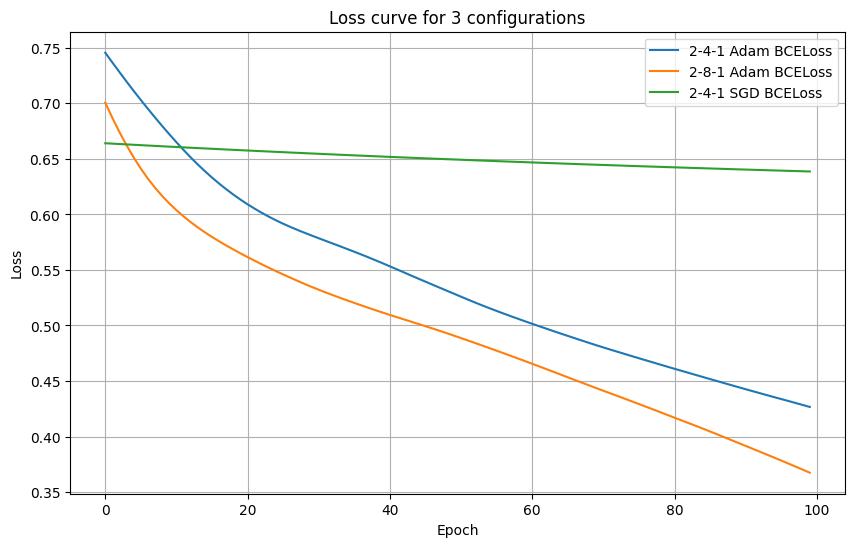

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# Tạo điểm cho lớp 0 (vòng tròn)
def generate_class_0(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(u)  # Bán kính nhỏ
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo điểm cho lớp 1 (vành đai)
def generate_class_1(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(3 * u + 1)  # Bán kính lớn hơn
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo dữ liệu
X_class0 = generate_class_0(100)
X_class1 = generate_class_1(200)
y_class0 = np.zeros(100)  # Nhãn 0
y_class1 = np.ones(200)   # Nhãn 1

# Kết hợp dữ liệu
X = np.vstack((X_class0, X_class1))
y = np.hstack((y_class0, y_class1))

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuyển sang tensor PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)  # Thêm chiều cho nhãn
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

# Xây dựng mô hình ANN cơ bản 
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.layer1 = nn.Linear(2, 4)  # Đầu vào 2, ẩn 4
        self.relu = nn.ReLU()          # Công tắc ReLU
        self.layer2 = nn.Linear(4, 1)  # Ẩn 4, đầu ra 1
        self.sigmoid = nn.Sigmoid()    # Xác suất 0-1

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

class ANN_2_8_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.sigmoid(self.layer2(x))
        return x

def train_trace(model, criterion, optimizer, epochs=100):
    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

model_c1 = ANN()
opt_c1 = optim.Adam(model_c1.parameters(), lr=0.01)
losses_c1 = train_trace(model_c1, nn.BCELoss(), opt_c1, epochs=100)

model_c2 = ANN_2_8_1()
opt_c2 = optim.Adam(model_c2.parameters(), lr=0.01)
losses_c2 = train_trace(model_c2, nn.BCELoss(), opt_c2, epochs=100)

model_c3 = ANN()
opt_c3 = optim.SGD(model_c3.parameters(), lr=0.01)
losses_c3 = train_trace(model_c3, nn.BCELoss(), opt_c3, epochs=100)

plt.figure(figsize=(10,6))
plt.plot(losses_c1, label='2-4-1 Adam BCELoss')
plt.plot(losses_c2, label='2-8-1 Adam BCELoss')
plt.plot(losses_c3, label='2-4-1 SGD BCELoss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss curve for 3 configurations')
plt.legend()
plt.grid(True)
plt.show()